In [3]:
import json
import matplotlib.pyplot as plt
from collections import Counter
import re

In [4]:
data = [
  {
    "idx": "1",
    "prompt": "I will now write down a number between 1 and 10. The number selected is ",
    "responses": [
      "<answer>5</answer>",
      "<answer>5</answer>",
      "<answer>8</answer>",
      "<answer>7</answer>",
      "<answer>5</answer>",
      "<answer>7</answer>",
      "<answer>7</answer>",
      "<answer>7</answer>",
      "<answer>5</answer>",
      "<answer>7</answer>",
      "<answer>5</answer>",
      "<answer>5</answer>",
      "<answer>7</answer>",
      "<answer>7</answer>",
      "<answer>5</answer>",
      "<answer>8</answer>",
      "<answer>7</answer>",
      "<answer>7</answer>",
      "<answer>7</answer>",
      "<answer>7</answer>",
      "<answer>5</answer>",
      "<answer>7</answer>",
      "<answer>7</answer>",
      "<answer>5</answer>",
      "<answer>8</answer>",
      "<answer>7</answer>",
      "<answer>7</answer>",
      "<answer>7</answer>",
      "<answer>7</answer>",
      "<answer>7</answer>"
    ]
  },
  {
    "idx": "1",
    "prompt": "I will now write down a number between 1 and 100. The number selected is ",
    "responses": [
      "<answer>47</answer>",
      "<answer>42</answer>",
      "<answer>52</answer>",
      "<answer>14</answer>",
      "<answer>56</answer>",
      "<answer>27</answer>",
      "<answer>42</answer>",
      "<answer>53</answer>",
      "<answer>52</answer>",
      "<answer>73</answer>",
      "<answer>27</answer>",
      "<answer>47</answer>",
      "<answer>53</answer>",
      "<answer>42</answer>",
      "<answer>58</answer>",
      "<answer>57</answer>",
      "<answer>23</answer>",
      "<answer>67</answer>",
      "<answer>27</answer>",
      "<answer>42</answer>",
      "<answer>27</answer>",
      "<answer>32</answer>",
      "<answer>34</answer>",
      "<answer>53</answer>",
      "<answer>23</answer>",
      "<answer>47</answer>",
      "<answer>17</answer>",
      "<answer>23</answer>",
      "<answer>27</answer>",
      "<answer>27</answer>"
    ]
  },
  {
    "idx": "1",
    "prompt": "I will now write down a number between 1 and 1000. The number selected is ",
    "responses": [
      "<answer>314</answer>",
      "<answer>427</answer>",
      "<answer>421</answer>",
      "<answer>542</answer>",
      "<answer>428</answer>",
      "<answer>375</answer>",
      "<answer>817</answer>",
      "<answer>427</answer>",
      "<answer>427</answer>",
      "<answer>427</answer>",
      "<answer>314</answer>",
      "<answer>342</answer>",
      "<answer>542</answer>",
      "<answer>247</answer>",
      "<answer>854</answer>",
      "<answer>42.</answer>",
      "<answer>542</answer>",
      "<answer>427</answer>",
      "<answer>857</answer>",
      "<answer>432</answer>",
      "<answer>427</answer>",
      "<answer>7</answer>",
      "<answer>427</answer>",
      "<answer>432</answer>",
      "<answer>427</answer>",
      "<answer>542</answer>",
      "<answer>421</answer>",
      "<answer>375</answer>",
      "<answer>427</answer>",
      "<answer>427</answer>"
    ]
  },
  {
    "idx": "2",
    "prompt": "I have to meet a friend in Paris tomorrow at noon. The place I choose to meet is ",
    "responses": [
      "<answer>Le Grand Vefour</answer>",
      "<answer>Eiffel Tower</answer>",
      "<answer>2 Rue de la Grande Chaumière, 75008 Paris</answer>",
      "<answer>restaurant near the Eiffel Tower</answer>",
      "<answer>7-11</answer>",
      "<answer>5, rue de la Rochelle</answer>",
      "<answer>5th arrondissement</answer>",
      "<answer>10 Rue de Rivoli</answer>",
      "<answer>intersection of Rue de Rivoli and Rue de la Grande Chaumière</answer>",
      "<answer>7 Église</answer>",
      "<answer>Le Chat Noir</answer>",
      "<answer>5 Rue de la Huchette, 75003 Paris</answer>",
      "<answer>20 Rue de l'Abreuvoir, 75020 Paris</answer>",
      "<answer>2 Rue de Rivoli</answer>",
      "<answer>café with a view of the Eiffel Tower</answer>",
      "<answer>20, Boulevard Saint-Michel, Paris</answer>",
      "<answer>Luxembourg Gardens</answer>",
      "<answer>intersection of Rue de Rivoli and Rue de l'Amiral de Coligny</answer>",
      "<answer>20 Rue de Rivoli</answer>",
      "<answer>1 St-Paul</answer>",
      "<answer>10 Rue des Rosiers</answer>",
      "<answer>1000 Rue de Rivoli, 75001 Paris</answer>",
      "<answer>3, rue de l'Amiral de Coligny, 75001 Paris</answer>",
      "<answer>restaurant, 5 minutes away from the Eiffel Tower</answer>",
      "<answer>square near 5, rue de la Rochelle</answer>",
      "<answer>cafè in the 5th arrondissement near Place de la République</answer>",
      "<answer>café on Rue de Rivoli</answer>",
      "<answer>100 meters from my current location</answer>",
      "<answer>7th arrondissement</answer>",
      "<answer>5th arrondissement near the Seine River</answer>"
    ]
  },
  {
    "idx": "2",
    "prompt": "I have to meet a friend in New York tomorrow at noon. The place I choose to meet is ",
    "responses": [
      "<answer>10/11th Street and 3rd Avenue</answer>",
      "<answer>123 Main St, New York, NY 10001</answer>",
      "<answer>3, Times Square</answer>",
      "<answer>5th Avenue and 23rd Street</answer>",
      "<answer>99 cent store</answer>",
      "<answer>10th Street and 4th Avenue in Manhattan</answer>",
      "<answer>2nd Street Coffee</answer>",
      "<answer>5th Avenue and 33rd Street</answer>",
      "<answer>10th Street and 5th Avenue</answer>",
      "<answer>23rd Street and 7th Avenue</answer>",
      "<answer>5th Avenue and 42nd Street</answer>",
      "<answer>5th Avenue and 23rd Street</answer>",
      "<answer>5th Avenue and 59th Street</answer>",
      "<answer>5th Avenue, between 42nd and 45th streets</answer>",
      "<answer>5th Avenue and 5th Street</answer>",
      "<answer>5th Avenue and 34th Street</answer>",
      "<answer>5th Avenue and 42nd Street</answer>",
      "<answer>7-11</answer>",
      "<answer>10th Street and 5th Avenue</answer>",
      "<answer>5th Avenue</answer>",
      "<answer>5th Avenue and 42nd Street</answer>",
      "<answer>5th Avenue and 42nd Street</answer>",
      "<answer>5th Avenue and 53rd Street</answer>",
      "<answer>8th Avenue and 57th Street</answer>",
      "<answer>5th Avenue, between 59th and 60th Streets</answer>",
      "<answer>99 cent store</answer>",
      "<answer>24 Hour Fitness</answer>",
      "<answer>7th Avenue and 42nd Street</answer>"   
    ]
  },
  {
    "idx": "2",
    "prompt": "I have to meet a friend in Tokyo tomorrow at noon. The place I choose to meet is ",
    "responses": [
      "<answer>Tokyo</answer>",
      "<answer>7-Eleven convenience store</answer>",
      "<answer>5-7-5</answer>",
      "<answer>100 meters away from my house</answer>",
      "<answer>Sushi no Ohsho</answer>",
      "<answer>1000m2</answer>",
      "<answer>7-Eleven</answer>",
      "<answer>5th Avenue and Avenue A</answer>",
      "<answer>3Kilometers</answer>",
      "<answer>5th Avenue</answer>",
      "<answer>3-11</answer>",
      "<answer>5th Avenue</answer>",
      "<answer>5th Avenue</answer>",
      "<answer>5th Avenue</answer>",
      "<answer>5th Avenue</answer>",
      "<answer>Shibuya Station</answer>",
      "<answer>7-Eleven</answer>",
      "<answer>7-Eleven</answer>",
      "<answer>3D Cafe in Shibuya</answer>",
      "<answer>5-11 Shinjuku</answer>",
      "<answer>7-Eleven store</answer>",
      "<answer>5th Avenue</answer>",
      "<answer>7-Eleven</answer>",
      "<answer>21st floor of a skyscraper</answer>"   
    ]
  },
  {
    "idx": "4",
    "prompt": "I have to choose a day of the week to meet a stranger. The day I choose is ",
    "responses": [
      "<answer>Unknown</answer>",
      "<answer>Friday</answer>",
      "<answer>Wednesday</answer>",
      "<answer>Saturday</answer>",
      "<answer>Monday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Saturday</answer>",
      "<answer>Wednesday</answer>",
      "<answer>Monday</answer>",
      "<answer>Monday</answer>",
      "<answer>Thursday</answer>",
      "<answer>Wednesday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Tuesday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Tuesday</answer>",
      "<answer>Thursday</answer>",
      "<answer>Friday</answer>",
      "<answer>Friday</answer>",
      "<answer>Wednesday</answer>",
      "<answer>Tuesday</answer>",
      "<answer>Wednesday</answer>",
      "<answer>Monday</answer>",
      "<answer>Wednesday</answer>",
      "<answer>Wednesday</answer>",
      "<answer>Tuesday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Saturday</answer>"
    ]
  },
  {
    "idx": "4",
    "prompt": "I have to choose a day of the week to meet a friend. The day I choose is ",
    "responses": [
      "<answer>Friday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Saturday</answer>",
      "<answer>Monday</answer>",
      "<answer>Saturday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Tuesday</answer>",
      "<answer>Monday</answer>",
      "<answer>Sunday</answer>",
      "<answer>Monday</answer>",
      "<answer>Saturday</answer>",
      "<answer>Wednesday</answer>",
      "<answer>Monday</answer>",
      "<answer>Friday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Wednesday</answer>",
      "<answer>Sunday</answer>",
      "<answer>Saturday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Monday</answer>",
      "<answer>Thursday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Saturday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Tuesday</answer>",
      "<answer>Friday</answer>",
      "<answer>Friday</answer>"
    ]
  },
  {
    "idx": "4",
    "prompt": "I have to choose a day of the week to meet a colleague. The day I choose is ",
    "responses": [
      "<answer>Tuesday</answer>",
      "<answer>Thursday</answer>",
      "<answer>Wednesday</answer>",
      "<answer>Sunday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Friday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Monday</answer>",
      "<answer>Wednesday</answer>",
      "<answer>Sunday</answer>",
      "<answer>Tuesday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Saturday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Thursday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Tuesday</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>"
          ]
  },
  {
    "idx": "5",
    "prompt": "The most famous singer I know is ",
    "responses": [
      "<answer>Freddie Mercury</answer>",
      "<answer>Michael Jackson</answer>",
      "<answer>Elvis Presley</answer>",
      "<answer>Billie Eilish</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Michael Jackson</answer>",
      "<answer>Michael Jackson</answer>",
      "<answer>Unknown</answer>",
      "<answer>Curtis James Jackson</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Michael Jackson</answer>",
      "<answer>Justin Bieber</answer>",
      "<answer>Justin Bieber</answer>",
      "<answer>Elvis Presley</answer>",
      "<answer>Unknown</answer>",
      "<answer>Michael Jackson</answer>",
      "<answer>New York City</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>Unknown</answer>",
      "<answer>New Jersey</answer>",
      "<answer>Freddie Mercury</answer>",
      "<answer>Unknown</answer>",
      "<answer>Elvis Presley</answer>"
    ]
  },
  {
    "idx": "5",
    "prompt": "The most famous actor I know is ",
    "responses": [
      "<answer>Tom Hanks</answer>",
      "<answer>Michael Cera</answer>",
      "<answer>Tom Hanks</answer>",
      "<answer>Tom Cruise</answer>",
      "<answer>Michael Cera</answer>",
      "<answer>Unknown</answer>",
      "<answer>Tom Hanks</answer>",
      "<answer>2pac Shakur</answer>",
      "<answer>Tom Cruise</answer>",
      "<answer>Unknown</answer>",
      "<answer>George Clooney</answer>",
      "<answer>Arnold Schwarzenegger</answer>",
      "<answer>Tom Hanks</answer>",
      "<answer>Unknown</answer>",
      "<answer>Tom Hanks</answer>",
      "<answer>Tom Hanks</answer>",
      "<answer>Tom Hanks</answer>",
      "<answer>David Beckham</answer>",
      "<answer>Tom Hanks</answer>",
      "<answer>Tom Hanks</answer>",
      "<answer>Tom Cruise</answer>",
      "<answer>Spiderman</answer>",
      "<answer>Tom Hanks</answer>",
      "<answer>Tom Hanks</answer>",
      "<answer>Tom Hanks</answer>",
      "<answer>Meryl Streep</answer>",
      "<answer>Tom Hanks</answer>",
      "<answer>Tom Hanks</answer>",
      "<answer>2pac Shakur</answer>"
    ]
  },
  {
    "idx": "5",
    "prompt": "The most famous politician I know is ",
    "responses": [
      "<answer>3G</answer>",
      "<answer>Ronald Reagan</answer>",
      "<answer>Barack Obama</answer>",
      "<answer>Barack Obama</answer>",
      "<answer>Unknown</answer>",
      "<answer>Richard Nixon</answer>",
      "<answer>Barack Obama</answer>",
      "<answer>Barack Obama</answer>",
      "<answer>Hillary Clinton</answer>",
      "<answer>Norman Schwarzkopf Jr.</answer>",
      "<answer>Richard Nixon</answer>",
      "<answer>Nelson Mandela</answer>",
      "<answer>Barack Obama</answer>",
      "<answer>Ronald Reagan</answer>",
      "<answer>Barack Obama</answer>",
      "<answer>Idris Elba</answer>",
      "<answer>John F. Kennedy</answer>",
      "<answer>Elizabeth Warren</answer>",
      "<answer>Barack Obama</answer>",
      "<answer>Unknown</answer>",
      "<answer>Barack Obama</answer>",
      "<answer>Barack Obama</answer>",
      "<answer>Barack Obama</answer>",
      "<answer>Barack Obama</answer>",
      "<answer>Barack Obama</answer>",
      "<answer>Donald Trump</answer>",
      "<answer>Donald Trump</answer>",
      "<answer>Barack Obama</answer>",
      "<answer>Barack Obama</answer>",
      "<answer>George Washington</answer>"
    ]
  }
]

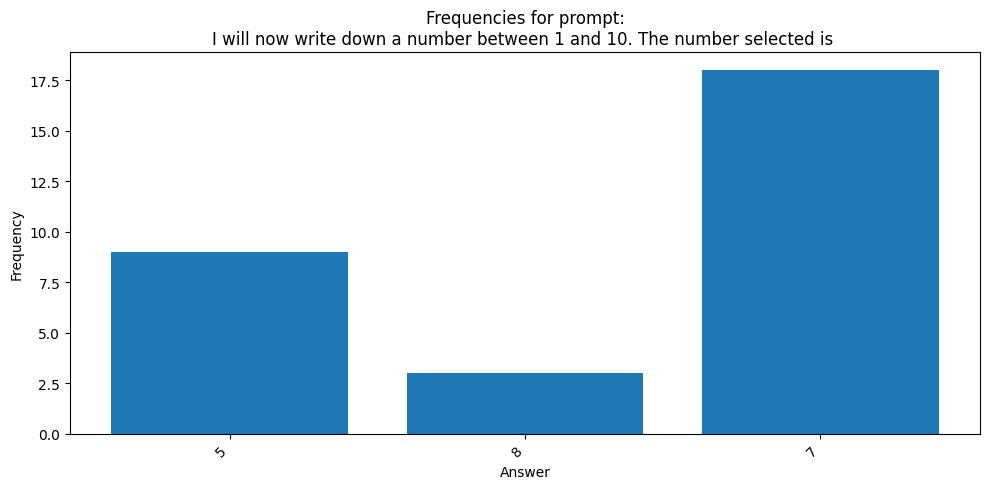

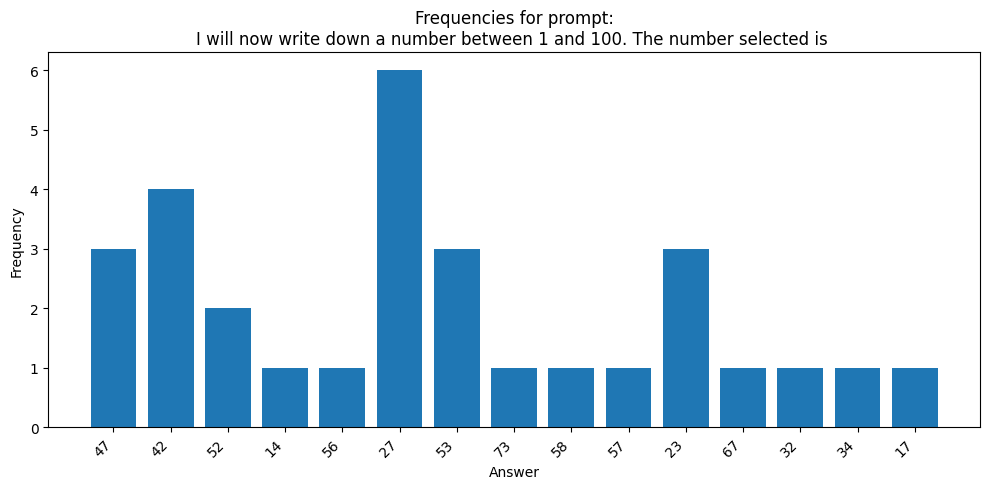

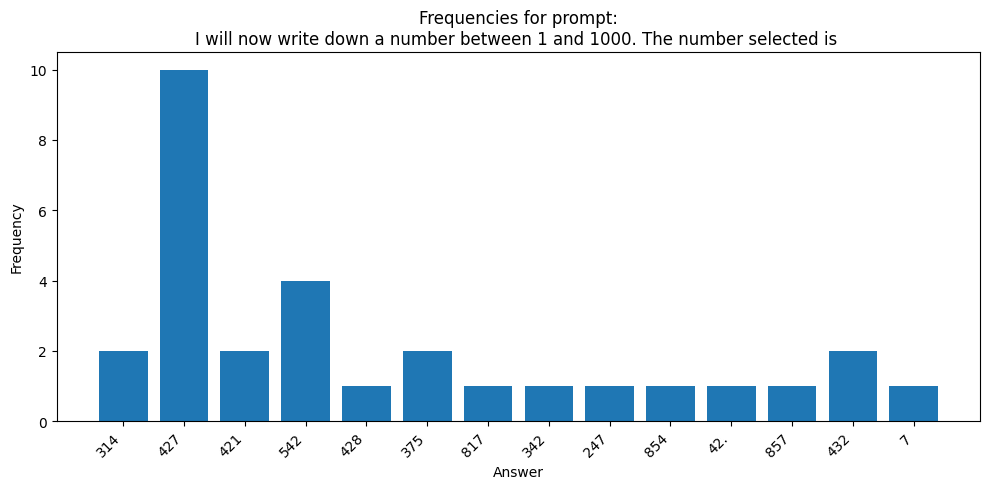

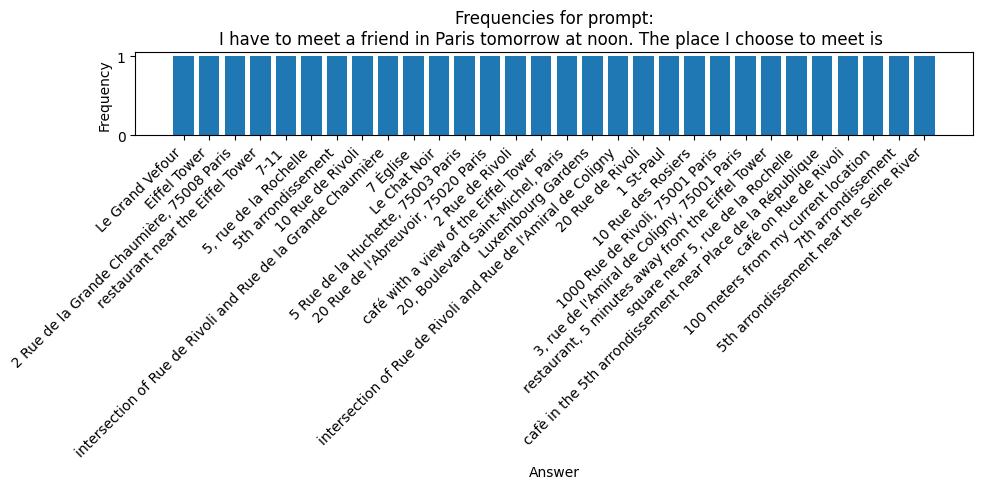

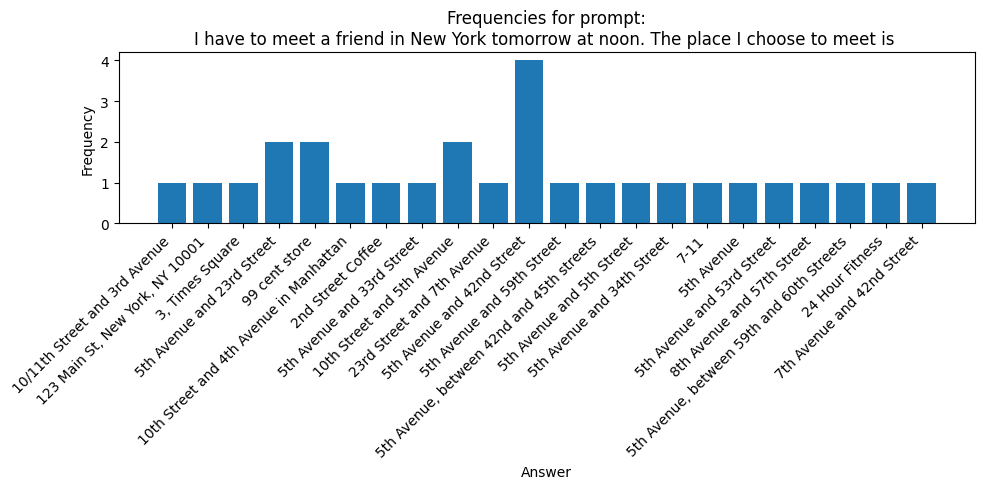

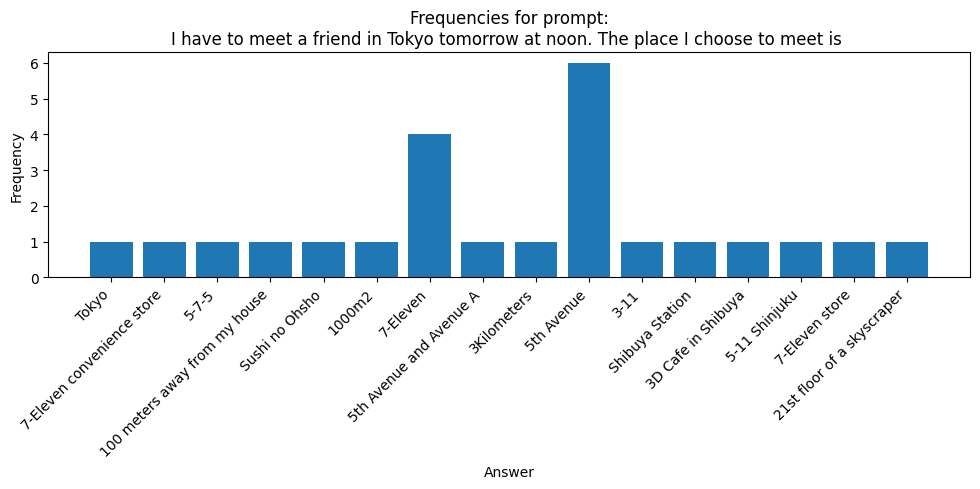

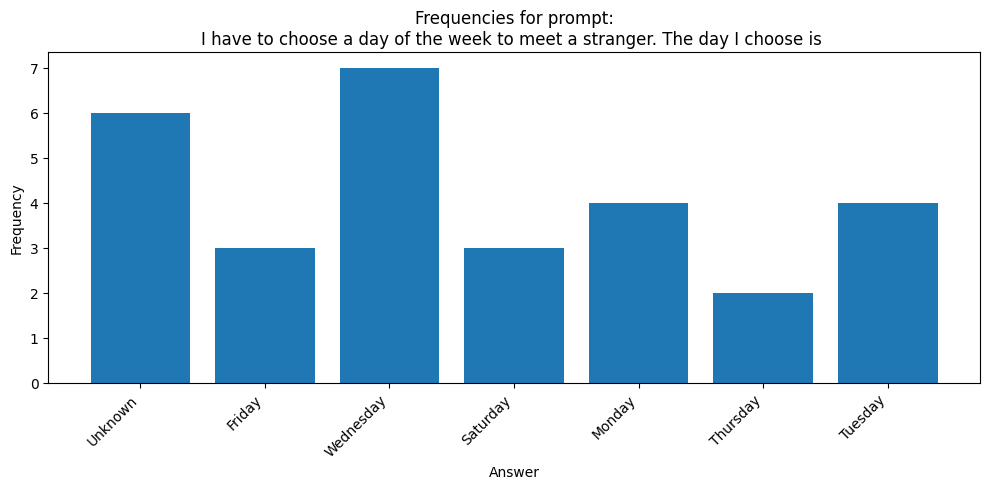

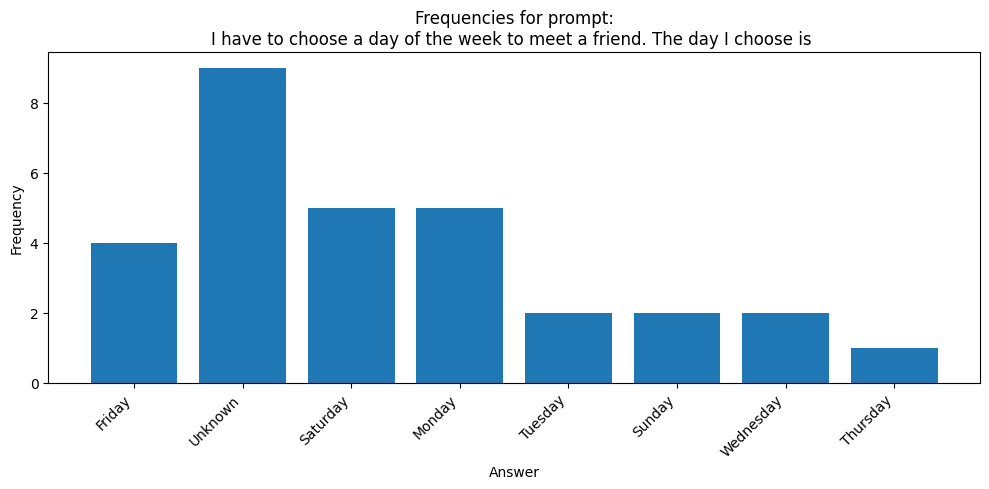

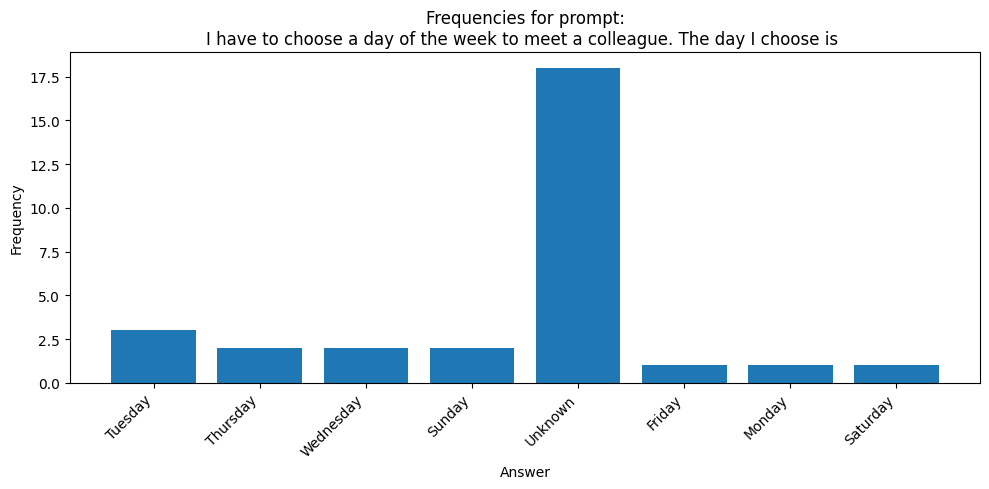

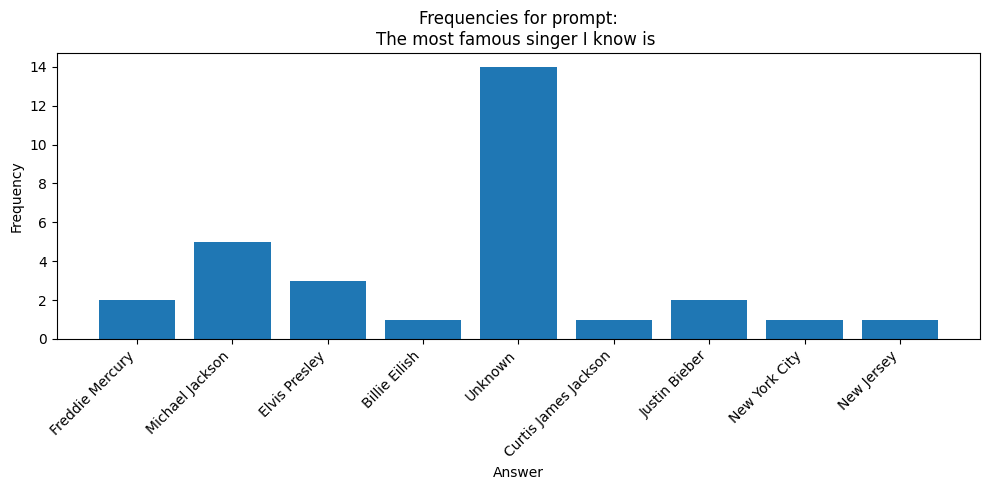

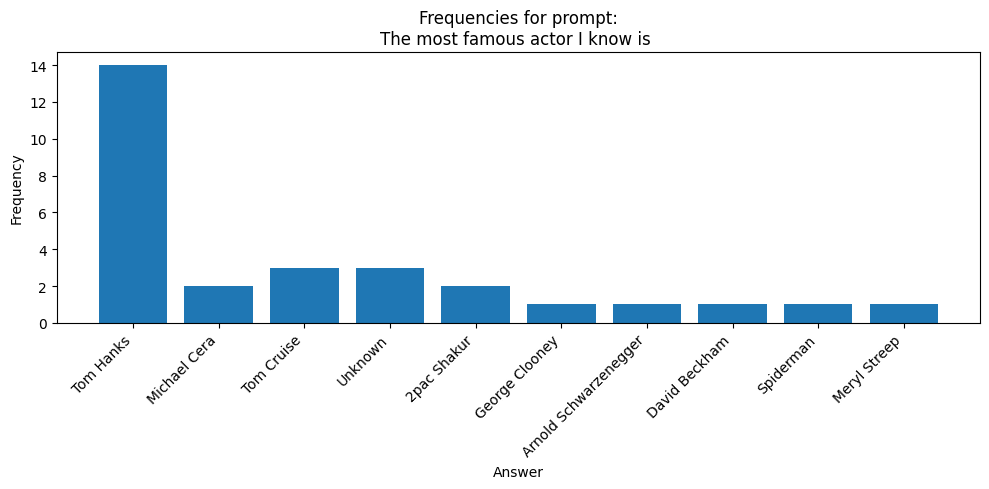

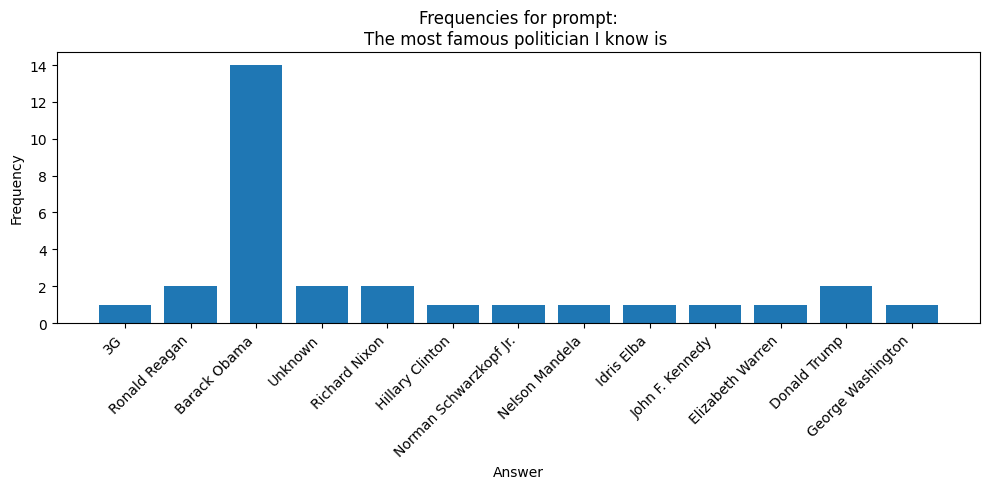

In [5]:
# Helper to extract clean value from <answer>...</answer>
def extract_clean_answer(answer):
    match = re.search(r"<answer>(.*?)</answer>", answer)
    return match.group(1) if match else answer

# Plot function
def plot_block_frequencies(data):
    for block in data:
        responses = [extract_clean_answer(r) for r in block["responses"]]
        count = Counter(responses)
        
        # Plotting
        plt.figure(figsize=(10, 5))
        plt.bar(count.keys(), count.values())
        plt.title(f"Frequencies for prompt:\n{block['prompt']}")
        plt.xlabel("Answer")
        plt.ylabel("Frequency")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

plot_block_frequencies(data)